In [372]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../../")))

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from bensemble.core.ensemble import Ensemble
from bensemble.metrics import expected_calibration_error, reliability_diagram
from bensemble.uncertainty.decomposition import decompose_classification_uncertainty
from bensemble.calibration.scaling import TemperatureScaling

torch.manual_seed(13)

Create ensemble of 5 random model.

In [373]:
models = [nn.Sequential(nn.Linear(10, 20), nn.ReLU(), nn.Linear(20, 3)) for _ in range(5)]

ensemble = Ensemble.from_models(models)

print(f"Ensenble has successfully created! The number of model: {ensemble.num_members}")

Ensenble has successfully created! The number of model: 5


Generate toy data with 3 classes. Then calculate ECE for uncalibrated logits.

In [374]:
x_test = torch.randn(1000, 10)
y_test = torch.randint(0, 3, (1000,))

with torch.no_grad():
    member_logits = ensemble.predict_members(x_test)
ensemble_logits = member_logits.mean(dim=0)
ensemble_probs = torch.softmax(ensemble_logits, dim=-1)

# Считаем ECE
ece_before = expected_calibration_error(ensemble_probs, y_test, n_bins=15)
print(f"Expected Calibration Error before calibration: {ece_before:.4f}")

Expected Calibration Error before calibration: 0.0440


Scale logits using ```TemperatureScaling``` and calculate new ECE.

In [375]:
scaler = TemperatureScaling(init_temp=1.0)
scaler.fit(ensemble_logits, y_test, max_iter=50)

print(f"Optimal temperature: {scaler.temperature.item():.4f}")

calibrated_logits = scaler(ensemble_logits)
calibrated_probs = torch.softmax(calibrated_logits, dim=-1)

ece_after = expected_calibration_error(calibrated_probs, y_test, n_bins=15)
print(f"Expected Calibration Error after calibration: {ece_after:.4f}")

Optimal temperature: 1.1791
Expected Calibration Error after calibration: 0.0375


Decompose variance of each model into aleatoric and epistemic variance.

In [379]:
member_probs = torch.softmax(member_logits, dim=-1)

total, aleatoric, epistemic = decompose_classification_uncertainty(member_probs)

for i in range(10):
    print(f"Example {i+1} | Total: {total[i]:.4f} | Aleatoric: {aleatoric[i]:.4f} | Epistemic: {epistemic[i]:.4f}")

Example 1 | Total: 1.0888 | Aleatoric: 1.0646 | Epistemic: 0.0242
Example 2 | Total: 1.0889 | Aleatoric: 1.0733 | Epistemic: 0.0155
Example 3 | Total: 1.0969 | Aleatoric: 1.0574 | Epistemic: 0.0395
Example 4 | Total: 1.0700 | Aleatoric: 1.0330 | Epistemic: 0.0371
Example 5 | Total: 1.0979 | Aleatoric: 1.0673 | Epistemic: 0.0306
Example 6 | Total: 1.0818 | Aleatoric: 1.0700 | Epistemic: 0.0118
Example 7 | Total: 1.0918 | Aleatoric: 1.0628 | Epistemic: 0.0290
Example 8 | Total: 1.0929 | Aleatoric: 1.0598 | Epistemic: 0.0330
Example 9 | Total: 1.0914 | Aleatoric: 1.0477 | Epistemic: 0.0437
Example 10 | Total: 1.0949 | Aleatoric: 1.0790 | Epistemic: 0.0159


Plot reliability diagrams for uncalibrated and calibrated logits

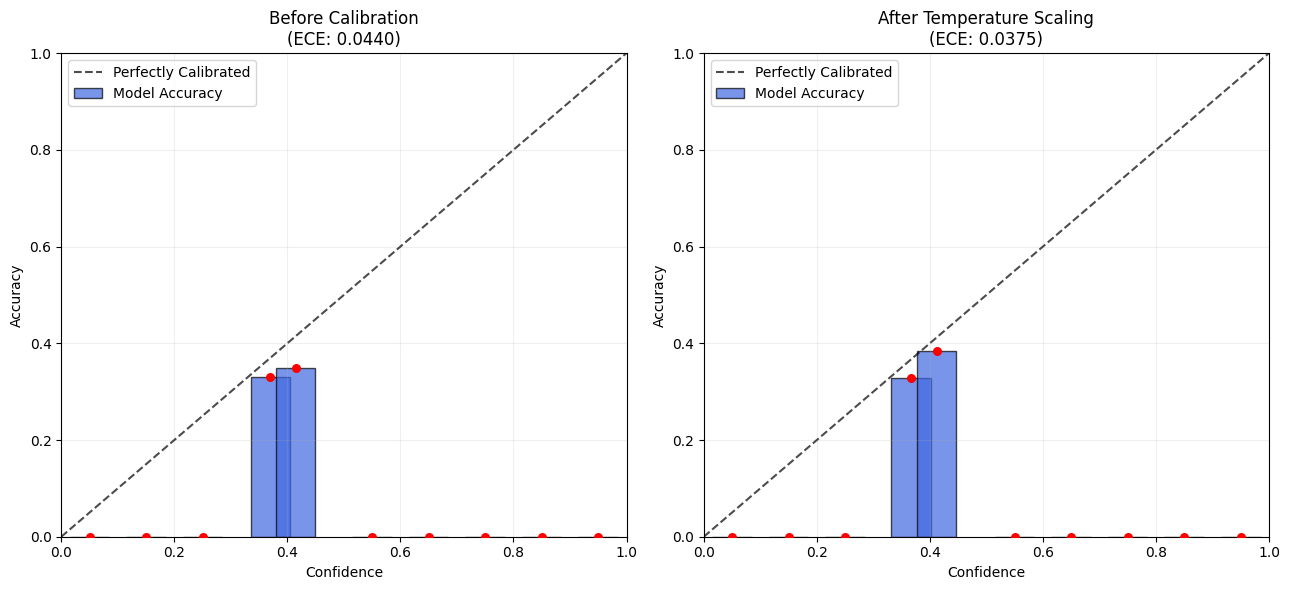

In [377]:
diagram_uncalibrated = reliability_diagram(ensemble_probs, y_test, n_bins=10)
diagram_data_calibrated = reliability_diagram(calibrated_probs, y_test, n_bins=10)

fig, ax = plt.subplots(1, 2, figsize=(13, 6))

for i, (data, title, ece) in enumerate([
    (diagram_uncalibrated, "Before Calibration", ece_before),
    (diagram_data_calibrated, "After Temperature Scaling", ece_after)
]):
    ax[i].plot([0, 1], [0, 1], 'k--', alpha=0.7, label="Perfectly Calibrated")
    
    ax[i].bar(data['confidences'], data['accuracies'], 
              width=0.07, alpha=0.7, color='royalblue', edgecolor='black', label='Model Accuracy')
    
    ax[i].scatter(data['confidences'], data['accuracies'], color='red', s=30, zorder=3)
    
    ax[i].set_xlim([0, 1])
    ax[i].set_ylim([0, 1])
    ax[i].set_xlabel("Confidence")
    ax[i].set_ylabel("Accuracy")
    ax[i].set_title(f"{title}\n(ECE: {ece:.4f})")
    ax[i].legend(loc="upper left")
    ax[i].grid(alpha=0.2)

plt.tight_layout()
plt.show()